The XOR classification problem is a classic problem for analyzing the capacity of a model with regard to capturing the nonlinear decision boundary between two classes.

 We will generate a toy dataset of 200 training examples with two features (x0, x1) drawn from a uniform distribution between [–1, 1).
 
  Then, we assign the ground truth label for training example i according to the following rule

  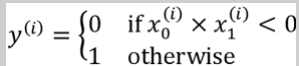

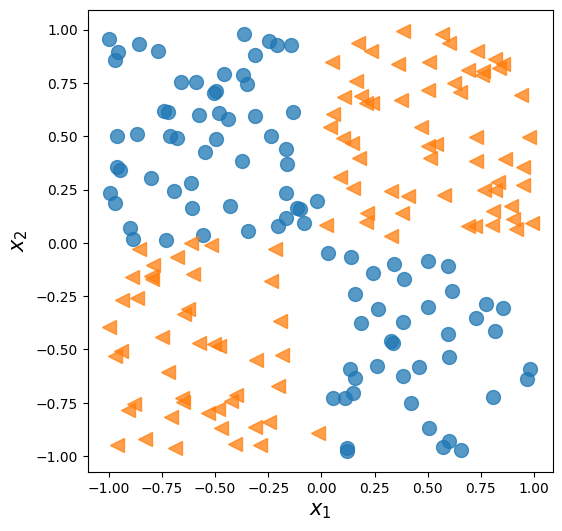

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import torch
torch.manual_seed(1)
np.random.seed(1)
x = np.random.uniform(low= -1, high = 1, size= (200,2))
y = np.ones(len(x))
y[x[:, 0] * x[:, 1] < 0]  = 0
n_train = 100
x_train = torch.tensor(x[:n_train, :], dtype= torch.float32)
y_train = torch.tensor(y[:n_train], dtype= torch.float32)
x_valid = torch.tensor(x[n_train:, :], dtype= torch.float32)
y_valid = torch.tensor(y[n_train:], dtype= torch.float32)
fig = plt.figure(figsize=(6, 6))
plt.plot(x[y==0, 0], x[y==0, 1], 'o', alpha=0.75, markersize=10)
plt.plot(x[y==1, 0], x[y==1, 1], '<', alpha=0.75, markersize=10)
plt.xlabel(r'$x_1$', size=15)
plt.ylabel(r'$x_2$', size=15)
plt.show()

In [4]:
import torch.nn as nn
model = nn.Sequential(nn.Linear(2, 4), nn.ReLU(), nn.Linear(4, 4), nn.ReLU(), nn.Linear(4, 1), nn.Sigmoid())
model

#lets initialize crosss enthropy loss function for binary classification and using SGD optimizer

loss_fn = nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr = 0.001)

# now lets create dataset and concanate them and use the batch size of 2 for train data note for sdg optimizer
from torch.utils.data import DataLoader, TensorDataset
train_ds = TensorDataset(x_train, y_train)
batch_size = 2
torch.manual_seed(1)
train_dl = DataLoader(train_ds, batch_size, shuffle= True)

# now lets train the model  for 200 epochs and record history 



Text(0.5, 0, 'Epochs')

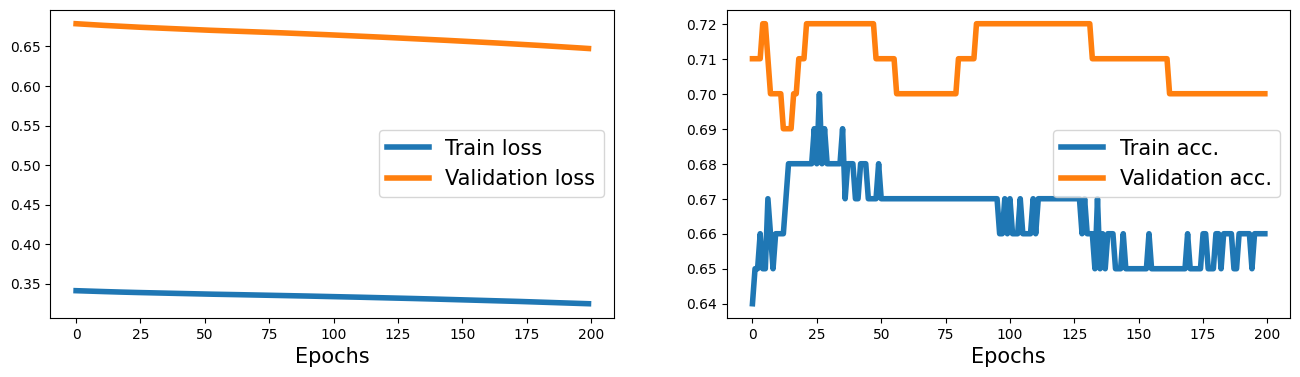

In [5]:
torch.manual_seed(12)
num_epochs = 200

def train(model, num_epochs, train_dl, x_valid, y_valid):
    train_loss_hist = [0] * num_epochs
    accuracy_hist_train = [0]* num_epochs
    loss_hist_valid = [0] * num_epochs
    accuracy_hist_valid = [0] * num_epochs
    for epoch in range(num_epochs):
        for x_batch, y_batch in train_dl:
            pred = model(x_batch)[:, 0]
            loss = loss_fn(pred, y_batch)
            loss.backward()
            
            optimizer.step() #applies sgd update
            optimizer.zero_grad()
            train_loss_hist[epoch] += loss.item()
            is_correct = ((pred>=0.5).float() == y_batch).float()
            accuracy_hist_train[epoch] += is_correct.mean()
            #accuracy_hist_train[epoch] /= n_train

        train_loss_hist[epoch] /= n_train
        accuracy_hist_train[epoch] /= n_train/batch_size
        pred = model(x_valid)[:, 0]
        loss = loss_fn(pred, y_valid)
        loss_hist_valid[epoch] = loss.item()
        is_correct = ((pred>=0.5).float() == y_valid).float()
        
        accuracy_hist_valid[epoch] += is_correct.mean()
    return train_loss_hist, loss_hist_valid, accuracy_hist_train, accuracy_hist_valid

history = train(model, num_epochs, train_dl, x_valid, y_valid)



fig = plt.figure(figsize=(16, 4))
ax = fig.add_subplot(1, 2, 1)
plt.plot(history[0], lw=4)
plt.plot(history[1], lw=4)
plt.legend(['Train loss', 'Validation loss'], fontsize=15)
ax.set_xlabel('Epochs', size=15)
ax = fig.add_subplot(1, 2, 2)
plt.plot(history[2], lw=4)
plt.plot(history[3], lw=4)
plt.legend(['Train acc.', 'Validation acc.'], fontsize=15)
ax.set_xlabel('Epochs', size=15)



as can seen above the simple model with no hidden layer can not solve the xor problem and the solution is to add other hidden layes via nonlinear activation and compare different numbers of hidden units until we observe satisfatory result on the validation dataset

Text(0.5, 0, 'Epochs')

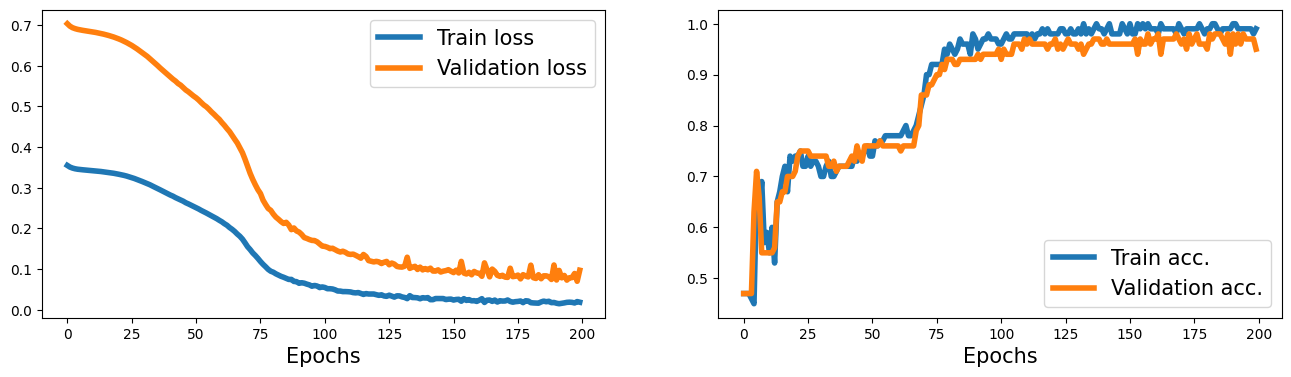

In [6]:

model = nn.Sequential(nn.Linear(2,4), nn.ReLU(), nn.Linear(4,4), nn.ReLU(), nn.Linear(4,1), nn.Sigmoid())
loss_fn = nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr = 0.015)


history = train(model, num_epochs, train_dl, x_valid,y_valid)



fig = plt.figure(figsize=(16, 4))
ax = fig.add_subplot(1, 2, 1)
plt.plot(history[0], lw=4)
plt.plot(history[1], lw=4)
plt.legend(['Train loss', 'Validation loss'], fontsize=15)
ax.set_xlabel('Epochs', size=15)
ax = fig.add_subplot(1, 2, 2)
plt.plot(history[2], lw=4)
plt.plot(history[3], lw=4)
plt.legend(['Train acc.', 'Validation acc.'], fontsize=15)
ax.set_xlabel('Epochs', size=15)



 to create more complex models that have multiple input, output, or intermediate branches in
 # Making model building more flexible with nn.Module


In [7]:
class MyModule(nn.Module):
    def __init__(self):
        super().__init__()
        l1 = nn.Linear(2,4)
        a1 = nn.ReLU()
        l2 = nn.Linear(4,4)
        a2 = nn.ReLU()
        l3 = nn.Linear(4,1)
        a3 = nn.Sigmoid()
        l = [l1,a1, l2, a2, l3, a3]
        self.model_list = nn.ModuleList(l)

    def forward(self,x):
        for f in self.model_list:
            x = f(x)
        return x

    def predict(self, x):
        x = torch.tensor(x, dtype = torch.float)
        pred = self.forward(x)[:,0]
        return (pred >= 0.5).float()
        

model = MyModule()
model
loss_fn = nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr = 0.015)
history = train(model, num_epochs, train_dl, x_valid, y_valid)



TypeError: Converting 'np.integer' or 'np.signedinteger' to a dtype is not allowed

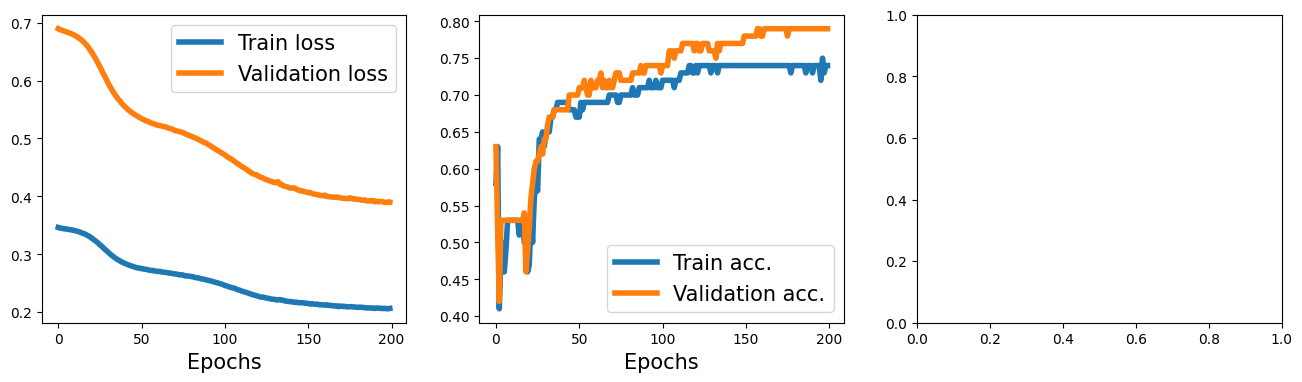

In [8]:
from mlxtend.plotting import plot_decision_regions
fig = plt.figure(figsize=(16, 4))
ax = fig.add_subplot(1, 3, 1)
plt.plot(history[0], lw=4)
plt.plot(history[1], lw=4)
plt.legend(['Train loss', 'Validation loss'], fontsize=15)
ax.set_xlabel('Epochs', size=15)
ax = fig.add_subplot(1, 3, 2)
plt.plot(history[2], lw=4)
plt.plot(history[3], lw=4)
plt.legend(['Train acc.', 'Validation acc.'], fontsize=15)
ax.set_xlabel('Epochs', size=15)
ax = fig.add_subplot(1, 3, 3)
plot_decision_regions(X=x_valid.numpy(),y=y_valid.numpy().astype(np.integer), clf=model)
ax.set_xlabel(r'$x_1$', size=15)
ax.xaxis.set_label_coords(1, -0.025)
ax.set_ylabel(r'$x_2$', size=15)
ax.yaxis.set_label_coords(-0.025, 1)
plt.show()

# Writing custom layers in PyTorch
to illustrate the concept of implementing the custorm laye lets try adding noise to the x
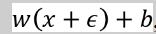

In [22]:
import torch

class NoisyLinear(nn.Module):
    def __init__(self, input_size, output_size, noise_stddev = 0.1):
        super().__init__()
        w = torch.Tensor(input_size, output_size) # initnalize numver of rows and columns
        self.w = nn.Parameter(w) # thisis for the  auto adjusting weihghts based on backpropagation
        nn.init.xavier_uniform_(self.w)
        b = torch.Tensor(output_size).fill_(0)
        self.b = nn.Parameter(b)
        self.noise_stddev = noise_stddev

    def forward(self,x, training = True):
        if training:
            noise = torch.normal(0.0, self.noise_stddev, x.shape)
            x_new =torch.add(x, noise)
        else:
            x_new = x

        return torch.add(torch.mm(x_new, self.w), self.b)
    



In [23]:
torch.manual_seed(1)
noisy_layer = NoisyLinear(4, 2)
x = torch.zeros((1, 4))
print(noisy_layer(x, training=True))
print(noisy_layer(x, training=True))
print(noisy_layer(x, training=False))


tensor([[ 0.1154, -0.0598]], grad_fn=<AddBackward0>)
tensor([[ 0.0432, -0.0375]], grad_fn=<AddBackward0>)
tensor([[0., 0.]], grad_fn=<AddBackward0>)
